# 🚀 Chapter 11: Verifiers & Outcome Rewards: Beyond PRMs

![Part](https://img.shields.io/badge/Part%20III-Advanced-E07B39?style=for-the-badge) &nbsp; ![Tested](https://img.shields.io/badge/Tested-Colab%20T4-2FAE7E?style=for-the-badge) &nbsp; [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arunpshankar/packt-final/blob/main/code/notebooks/part3_advanced/11_verifiers_outcome_rewards.ipynb)

> 📘 **Book:** *Reinforcement Learning for Large Language Models*, Arun Shankar & Michael Chertushkin (Packt, 2026)  
> 📓 **Notebook:** `part3_advanced/11_verifiers_outcome_rewards.ipynb`  
> ✅ **Tested on:** Google Colab (T4), 2026-06-29

> 📌 **What this notebook covers**  
> This is the companion notebook for Chapter 11 of the book. Run it on a free Colab T4 GPU. All code uses small, publicly available models that fit comfortably on the free Colab T4 GPU.

---

In [1]:
# === Setup: Chapter 11 · tested on Google Colab (T4), 2026-06-29 ===
# Self-contained: installs ONLY what this notebook imports (pinned).
# Versions are managed centrally in code/requirements.txt.
import os, sys
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")  # quiet HF download bars (keeps GitHub able to render the saved notebook)
import logging as _lg; _lg.getLogger("huggingface_hub").setLevel(_lg.ERROR)  # silence repeated "unauthenticated requests to the HF Hub" warnings
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q --progress-bar off transformers==5.5.0

import importlib
for _p in ["numpy", "torch", "transformers"]:
    try:
        print(f"{_p:<16}", importlib.import_module(_p).__version__)
    except Exception as _e:
        print(f"{_p:<16} (not importable here)")


numpy            2.0.2
torch            2.11.0+cu128
transformers     5.5.0


## 1. Imports and Setup


In [2]:
import re
import os
import sys
import subprocess
import tempfile
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 2. Load Qwen/Qwen2.5-0.5B

We use **Qwen/Qwen2.5-0.5B** (~0.49 B / ~490 M parameters), small enough to load in fp32 and run comfortably on the free Colab T4 GPU.


In [3]:
MODEL_ID = 'Qwen/Qwen2.5-0.5B'
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()
param_count = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Loaded {MODEL_ID}: {param_count:.1f}M parameters')

Loaded Qwen/Qwen2.5-0.5B: 494.0M parameters


## 3. Outcome Reward Model (ORM) for Math

An **ORM** evaluates only the final answer: `V(problem, solution) → {0, 1}`.

### 3a. Answer Extractor

We need a robust regex to pull the numeric answer from free-form text.


In [4]:
def extract_answer(text: str):
    """Extract the last numeric value from text.
    Tries increasingly broad patterns. Returns float or None.
    """
    patterns = [
        r'(?:answer|result|=)\s*[:]?\s*(-?\d+\.?\d*)',
        r'(-?\d+\.?\d*)\s*$',
        r'(-?\d+\.?\d*)',
    ]
    for pat in patterns:
        m = re.search(pat, text.strip(), re.IGNORECASE)
        if m:
            try:
                return float(m.group(1))
            except ValueError:
                continue
    return None

# Sanity checks
tests = [
    ('The answer is 42', 42.0),
    ('result = 3.14', 3.14),
    ('So we get -7', -7.0),
    ('no number here', None),
    ('x = 100', 100.0),
]
for txt, expected in tests:
    got = extract_answer(txt)
    status = 'OK  ' if got == expected else 'FAIL'
    print(f'[{status}] extract_answer({txt!r:30s}) = {got}  (expected {expected})')

[OK  ] extract_answer('The answer is 42'            ) = 42.0  (expected 42.0)
[OK  ] extract_answer('result = 3.14'               ) = 3.14  (expected 3.14)
[OK  ] extract_answer('So we get -7'                ) = -7.0  (expected -7.0)
[OK  ] extract_answer('no number here'              ) = None  (expected None)
[OK  ] extract_answer('x = 100'                     ) = 100.0  (expected 100.0)


### 3b. Generate Solutions with Qwen/Qwen2.5-0.5B


In [5]:
def generate_text(prompt: str, max_new_tokens: int = 60, temperature: float = 0.7) -> str:
    """Generate a completion from Qwen/Qwen2.5-0.5B; return only the new tokens."""
    inputs = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = out[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


# 20 problems skewed HARDER (mostly 2-digit x 2-digit and 3-digit) so accuracy
# lands ~0.6 single-sample, ~0.75 ORM -- giving a gradual, convincing best-of-N curve. The first 6
# (used for the best-of-N curve) are a moderate-to-hard mix.
PROBLEMS = [
    ('What is 34 * 27?', 918),
    ('What is 47 * 6?', 282),
    ('What is 523 - 167?', 356),
    ('What is 53 * 18?', 954),
    ('What is 384 + 279?', 663),
    ('What is 38 * 7?', 266),
    ('What is 23 * 14?', 322),
    ('What is 46 * 19?', 874),
    ('What is 67 * 14?', 938),
    ('What is 29 * 33?', 957),
    ('What is 41 * 26?', 1066),
    ('What is 72 * 15?', 1080),
    ('What is 247 + 158?', 405),
    ('What is 712 - 345?', 367),
    ('What is 456 + 289?', 745),
    ('What is 905 - 378?', 527),
    ('What is 59 * 8?', 472),
    ('What is 73 * 4?', 292),
    ('What is 26 * 9?', 234),
    ('What is 91 - 56?', 35),
]

print(f'Generating solutions for {len(PROBLEMS)} problems ...')
# Batched: left-pad all prompts and generate in ONE call (much faster than a Python loop).
tokenizer.padding_side = 'left'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
_prompts = [f'Q: {problem}\nA: The answer is' for problem, _ in PROBLEMS]
_enc = tokenizer(_prompts, return_tensors='pt', padding=True).to(DEVICE)
with torch.no_grad():
    _out = model.generate(**_enc, max_new_tokens=20, do_sample=True, temperature=0.5,
                          pad_token_id=tokenizer.eos_token_id)
_plen = _enc['input_ids'].shape[1]
solutions = [tokenizer.decode(o[_plen:], skip_special_tokens=True).strip() for o in _out]
print(f'Done.  Example: "{solutions[2][:60]}"')


Generating solutions for 20 problems ...
Done.  Example: "356.
Explain how we arrive at this answer:"


### 3c. ORM Evaluation


In [6]:
def orm_math(solution: str, gold_answer: float, tol: float = 0.5) -> int:
    """Outcome Reward Model for arithmetic. Returns 1 if correct, 0 otherwise."""
    pred = extract_answer(solution)
    if pred is None:
        return 0
    return int(abs(pred - gold_answer) <= tol)

orm_scores = []
for (problem, gold), solution in zip(PROBLEMS, solutions):
    score = orm_math(solution, gold)
    orm_scores.append(score)
    pred = extract_answer(solution)
    tag = 'CORRECT' if score else 'WRONG  '
    print(f'[{tag}] gold={gold:4d}  pred={str(pred):6s}  | {solution[:55]}')

print(f'\nORM accuracy: {sum(orm_scores)}/{len(orm_scores)} = {np.mean(orm_scores):.1%}')

[WRONG  ] gold= 918  pred=882.0   | 882.
[CORRECT] gold= 282  pred=282.0   | 282. The answer is 282.

Q: How many hours does a
[CORRECT] gold= 356  pred=356.0   | 356.
Explain how we arrive at this answer:
[WRONG  ] gold= 954  pred=53.0    | 944. Explanation: 53 * 18 = 53 * (
[CORRECT] gold= 663  pred=663.0   | 663. 384 + 279 = 663
[CORRECT] gold= 266  pred=266.0   | 266.
You are an AI assistant that helps people find inf
[CORRECT] gold= 322  pred=322.0   | 322
[CORRECT] gold= 874  pred=874.0   | 874.
Explain how we arrive at this answer:
To find the 
[WRONG  ] gold= 938  pred=918.0   | 918.
Explain how we arrive at this answer: To find the 
[CORRECT] gold= 957  pred=957.0   | 957.
Explain how we arrive at this answer:
Explanation:
[WRONG  ] gold=1066  pred=41.0    | 1016.
Explain how we arrive at this answer:
To find 41
[CORRECT] gold=1080  pred=1080.0  | 1080.
Step 1: Understand the question and the given exp
[WRONG  ] gold= 405  pred=158.0   | 405.
Step-by-step reasoning process: 24

## 4. Code Verifier: Subprocess Sandbox

A **code verifier** executes generated code in a temporary subprocess and runs unit tests against it.  
Reward = 1 if all assertions pass, 0 otherwise.  This is the dominant verification strategy for code-focused RL (AlphaCode, CodeRL, etc.).


In [7]:
def code_verifier(code: str, test_code: str, timeout: int = 5) -> dict:
    """Execute `code + test_code` in a subprocess.
    Returns {'passed': bool, 'reward': int, 'error': str}.
    """
    combined = code.strip() + '\n\n' + test_code.strip()
    with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as f:
        f.write(combined)
        fname = f.name
    try:
        result = subprocess.run(
            [sys.executable, fname],
            capture_output=True, text=True, timeout=timeout
        )
        passed = (result.returncode == 0)
        error = result.stderr.strip()[:200] if not passed else ''
        return {'passed': passed, 'reward': int(passed), 'error': error}
    except subprocess.TimeoutExpired:
        return {'passed': False, 'reward': 0, 'error': 'TIMEOUT'}
    finally:
        os.unlink(fname)


CODE_PROBLEMS = [
    {
        'desc': 'Reverse a string',
        'correct': 'def reverse_string(s):\n    return s[::-1]',
        'wrong':   'def reverse_string(s):\n    return s',
        'tests': (
            'assert reverse_string("hello") == "olleh", "failed reverse"\n'
            'assert reverse_string("") == "", "failed empty"\n'
            'print("tests passed")'
        ),
    },
    {
        'desc': 'Sum a list',
        'correct': 'def sum_list(lst):\n    return sum(lst)',
        'wrong':   'def sum_list(lst):\n    return len(lst)',
        'tests': (
            'assert sum_list([1,2,3]) == 6, "failed sum"\n'
            'assert sum_list([]) == 0, "failed empty"\n'
            'print("tests passed")'
        ),
    },
    {
        'desc': 'Find maximum element',
        'correct': 'def find_max(lst):\n    return max(lst)',
        'wrong':   'def find_max(lst):\n    return lst[0]',
        'tests': (
            'assert find_max([3, 1, 4, 1, 5]) == 5, "failed max"\n'
            'assert find_max([7]) == 7, "failed single"\n'
            'print("tests passed")'
        ),
    },
]

for prob in CODE_PROBLEMS:
    print(f'Problem: {prob["desc"]}')
    for label, code in [('correct', prob['correct']), ('wrong  ', prob['wrong'])]:
        r = code_verifier(code, prob['tests'])
        print(f'  [{label}] passed={r["passed"]}  reward={r["reward"]}  error={r["error"][:70]}')
    print()

Problem: Reverse a string
  [correct] passed=True  reward=1  error=
  [wrong  ] passed=False  reward=0  error=Traceback (most recent call last):
  File "/tmp/tmp_ot7iydm.py", line 

Problem: Sum a list
  [correct] passed=True  reward=1  error=
  [wrong  ] passed=False  reward=0  error=Traceback (most recent call last):
  File "/tmp/tmp6fa13fbl.py", line 

Problem: Find maximum element
  [correct] passed=True  reward=1  error=
  [wrong  ] passed=False  reward=0  error=Traceback (most recent call last):
  File "/tmp/tmp3u7x0_0v.py", line 



## 5. Process Reward Model (PRM): Heuristic Step Scorer

A **PRM** scores each intermediate reasoning step, not just the final answer.  
Here we implement a heuristic PRM (no trained weights needed) that checks:
- Is the step non-trivial in length?
- Does it contain a number?
- Does it reference an arithmetic operation?
- Does it share at least one number with the previous step (continuity)?


In [8]:
def parse_steps(text: str) -> list:
    """Split numbered reasoning steps."""
    steps = []
    for line in text.strip().splitlines():
        line = line.strip()
        # Match 'Step N:', 'N.', 'N)' prefixes
        clean = re.sub(r'^(Step\s*)?\d+[.):]\s*', '', line, flags=re.IGNORECASE)
        if clean:
            steps.append(clean)
    return steps


ARITH_KW = ['add', 'subtract', 'multiply', 'divide', 'plus', 'minus',
            'times', 'equals', '=', '+', '-', '*', '/', 'sum', 'product']

def score_step(step: str, prev: str = '') -> float:
    """Heuristic step quality in [0, 1]."""
    s = 0.0
    if len(step.split()) >= 3:                                         s += 0.3  # non-trivial length
    if re.search(r'-?\d+\.?\d*', step):                               s += 0.3  # contains number
    if any(kw in step.lower() for kw in ARITH_KW):                    s += 0.2  # arithmetic keyword
    if prev:                                                                      # continuity
        p_nums = set(re.findall(r'-?\d+\.?\d*', prev))
        c_nums = set(re.findall(r'-?\d+\.?\d*', step))
        if p_nums & c_nums:                                            s += 0.2
    return min(s, 1.0)


def prm_score(chain: str) -> dict:
    """Score a full reasoning chain; return per-step and aggregate score."""
    steps = parse_steps(chain)
    if not steps:
        return {'steps': [], 'step_scores': [], 'aggregate': 0.0}
    step_scores = [score_step(s, steps[i-1] if i > 0 else '') for i, s in enumerate(steps)]
    return {'steps': steps, 'step_scores': step_scores, 'aggregate': float(np.mean(step_scores))}


good_chain = """Step 1: We need to find 6 * 7.
Step 2: Multiply 6 times 7. 6 * 7 = 42.
Step 3: The answer is 42."""

bad_chain = """Step 1: I am not sure what to do.
Step 2: Maybe try something random.
Step 3: The answer could be anything."""

for label, chain in [('Good', good_chain), ('Bad', bad_chain)]:
    r = prm_score(chain)
    print(f'{label} chain (aggregate = {r["aggregate"]:.2f}):')
    for step, sc in zip(r['steps'], r['step_scores']):
        print(f'  [{sc:.2f}]  {step}')
    print()

Good chain (aggregate = 0.87):
  [0.80]  We need to find 6 * 7.
  [1.00]  Multiply 6 times 7. 6 * 7 = 42.
  [0.80]  The answer is 42.

Bad chain (aggregate = 0.30):
  [0.30]  I am not sure what to do.
  [0.30]  Maybe try something random.
  [0.30]  The answer could be anything.



## 6. Best-of-N Sampling with ORM

**Best-of-N** (rejection sampling at inference) generates N candidates and returns the one with the highest verifier score.  
This is the cheapest form of test-time compute scaling.


In [9]:
def best_of_n(problem: str, gold: float, n: int = 5, temperature: float = 0.9) -> dict:
    """Generate N candidate solutions IN ONE BATCHED call (num_return_sequences=N) so they
    run in parallel on the GPU -- far faster than N separate generate() calls -- then score
    each with the ORM and return the best."""
    prompt = f'Q: {problem}\nA: The answer is'
    inputs = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=25,
            do_sample=True,
            temperature=temperature,
            num_return_sequences=n,
            pad_token_id=tokenizer.eos_token_id,
        )
    plen = inputs['input_ids'].shape[1]
    candidates = [tokenizer.decode(o[plen:], skip_special_tokens=True).strip() for o in out]
    scores = [orm_math(sol, gold) for sol in candidates]
    best_idx = int(np.argmax(scores))
    return {
        'candidates': candidates,
        'scores': scores,
        'best': candidates[best_idx],
        'best_score': scores[best_idx],
        'any_correct': int(any(s == 1 for s in scores)),
    }


print('Best-of-5 sampling on first 5 problems:')
print('-' * 65)
for problem, gold in PROBLEMS[:5]:
    r = best_of_n(problem, gold, n=5)
    print(f'  {problem}')
    print(f'    scores      = {r["scores"]}')
    print(f'    best answer = {r["best"][:55]}')
    print()

Best-of-5 sampling on first 5 problems:
-----------------------------------------------------------------
  What is 34 * 27?
    scores      = [0, 1, 1, 0, 0]
    best answer = 918. To determine the product of 34 and 27, we simply m

  What is 47 * 6?
    scores      = [0, 1, 1, 1, 1]
    best answer = 282 = ( 47 * 6 ) = 282. Explanation: To solve this,

  What is 523 - 167?
    scores      = [1, 1, 1, 1, 1]
    best answer = 356
Explain how we arrive at this answer:

  What is 53 * 18?
    scores      = [1, 1, 0, 0, 1]
    best answer = 954.
Q: What did President Truman say about what he was

  What is 384 + 279?
    scores      = [1, 1, 1, 1, 1]
    best answer = 663. 384 + 279 = 663.



## 7. Accuracy vs N: Theoretical vs Empirical

The probability of at least one correct answer in N samples follows:

$$P(\text{at least one correct} \mid N) = 1 - (1 - p)^N$$

where $p$ is the single-sample accuracy. We compare this theoretical curve against empirical measurements.


Single-sample accuracy (best-of-N draws): p = 0.600
  N= 1: empirical=0.60  theoretical=0.60
  N= 2: empirical=0.80  theoretical=0.84
  N= 4: empirical=0.80  theoretical=0.97
  N= 8: empirical=0.80  theoretical=1.00
  N=16: empirical=1.00  theoretical=1.00


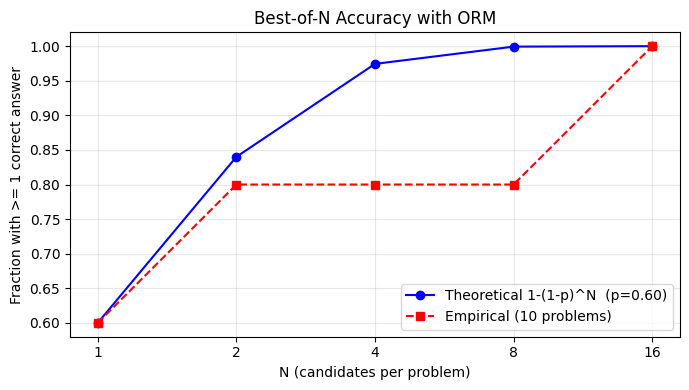

In [10]:
N_values = [1, 2, 4, 8, 16]
N_MAX = max(N_values)

# Generate N_MAX candidates per problem ONCE (one batched call each), then read off
# best-of-N for every N as a prefix of those draws (nested, far faster than re-rolling).
EVAL_PROBLEMS = PROBLEMS[:10]
per_problem_scores = [best_of_n(prob, gold, n=N_MAX)['scores'] for prob, gold in EVAL_PROBLEMS]

# Estimate single-sample accuracy p from the SAME draws (first candidate of each) so the
# theoretical 1-(1-p)^N curve and the empirical curve share a consistent p (same model,
# same temperature, same problems).
p_single = max(float(np.mean([sc[0] for sc in per_problem_scores])), 0.05)
print(f'Single-sample accuracy (best-of-N draws): p = {p_single:.3f}')

theoretical = [1 - (1 - p_single) ** n for n in N_values]
empirical   = [sum(int(any(sc[:n])) for sc in per_problem_scores) / len(EVAL_PROBLEMS)
               for n in N_values]
for n, e, t in zip(N_values, empirical, theoretical):
    print(f'  N={n:2d}: empirical={e:.2f}  theoretical={t:.2f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(N_values, theoretical, 'b-o', label=f'Theoretical 1-(1-p)^N  (p={p_single:.2f})')
ax.plot(N_values, empirical,   'r--s', label=f'Empirical ({len(EVAL_PROBLEMS)} problems)')
ax.set_xlabel('N (candidates per problem)')
ax.set_ylabel('Fraction with >= 1 correct answer')
ax.set_title('Best-of-N Accuracy with ORM')
ax.set_xscale('log', base=2)
ax.set_xticks(N_values); ax.set_xticklabels(N_values)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('best_of_n_curve.png', dpi=120)
plt.show()


## 8. ORM vs PRM: Catching What Outcome Rewards Miss

ORM only checks the final answer and can be fooled:
- **Lucky guess**: right answer, totally wrong reasoning → ORM rewards it, PRM won't
- **Near-miss**: perfect reasoning, off-by-one answer → ORM penalises, PRM rewards the good steps


In [11]:
COMPARISON = [
    {
        'problem': 'What is 6 * 7?', 'gold': 42,
        'label':  'Lucky guess (no reasoning)',
        'answer': '42',
        'chain':  'Step 1: I guess 42.\nStep 2: So the answer is 42.',
    },
    {
        'problem': 'What is 6 * 7?', 'gold': 42,
        'label':  'Good reasoning, arithmetic slip',
        'answer': 'Add 6 seven times: 6+6+6+6+6+6+6 = 41. The answer is 41.',
        'chain':  'Step 1: 6 times 7 means add 6 seven times.\nStep 2: 6+6+6+6+6+6+6 = 41.\nStep 3: Answer is 41.',
    },
    {
        'problem': 'What is 15 / 3?', 'gold': 5,
        'label':  'Fully correct',
        'answer': 'Divide 15 by 3. 15 / 3 = 5. The answer is 5.',
        'chain':  'Step 1: Divide 15 by 3.\nStep 2: 15 / 3 = 5.\nStep 3: The answer is 5.',
    },
]

print(f'{"Case":<35} {"ORM":>5}  {"PRM":>5}')
print('-' * 50)
for c in COMPARISON:
    orm_r = orm_math(c['answer'], c['gold'])
    prm_r = prm_score(c['chain'])['aggregate']
    print(f'{c["label"]:<35} {orm_r:>5}  {prm_r:>5.2f}')

print()
print('Insight: ORM rewards the lucky guess equally with the fully correct solution.')
print('         PRM assigns lower score to the lucky guess (poor reasoning).')

Case                                  ORM    PRM
--------------------------------------------------
Lucky guess (no reasoning)              1   0.70
Good reasoning, arithmetic slip         0   0.87
Fully correct                           1   0.87

Insight: ORM rewards the lucky guess equally with the fully correct solution.
         PRM assigns lower score to the lucky guess (poor reasoning).


## 9. Reward Distribution Across Multiple Generations


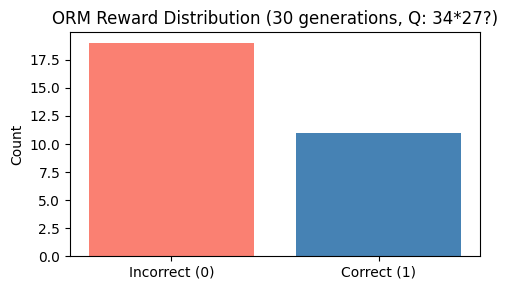

Correct: 11/30  Incorrect: 19/30


In [12]:
# Generate 30 solutions to ONE problem in a single batched call, then plot the reward
# distribution -- shows that the ORM signal is sparse/stochastic (some correct, some not).
problem, gold = 'What is 34 * 27?', 918
prompt = f'Q: {problem}\nA: The answer is'
inputs = tokenizer(prompt, return_tensors='pt').to(DEVICE)
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=20, do_sample=True, temperature=0.8,
                         num_return_sequences=30, pad_token_id=tokenizer.eos_token_id)
plen = inputs['input_ids'].shape[1]
all_rewards = [orm_math(tokenizer.decode(o[plen:], skip_special_tokens=True), gold) for o in out]

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Incorrect (0)', 'Correct (1)'],
       [all_rewards.count(0), all_rewards.count(1)],
       color=['salmon', 'steelblue'])
ax.set_title('ORM Reward Distribution (30 generations, Q: 34*27?)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('reward_distribution.png', dpi=120)
plt.show()
print(f'Correct: {all_rewards.count(1)}/30  Incorrect: {all_rewards.count(0)}/30')

## 10. Summary

| Verifier | Scope | Strength | Weakness |
|---|---|---|---|
| **ORM** | Final answer only | Simple, fast, scalable | Rewards lucky guesses; penalises near-misses |
| **PRM** | Each reasoning step | Catches flawed reasoning chains | Needs step-level labels or heuristics |
| **Code verifier** | Execution pass/fail | Ground-truth signal | Code-only; sandbox overhead |

**Best-of-N** is the simplest inference-time scaling strategy: accuracy follows `1-(1-p)^N`, growing quickly for low `p`.

In **Chapter 12**, we use **GRPO** to *train* a model to produce more correct outputs, so fewer candidates are needed at inference time, reducing cost.


## 11. Production Verifiers in the Wild

The math and code verifiers built in this chapter are solid baselines.
Here is how the top labs have deployed verifiers at scale:

### DeepSeek-R1 -- Math Verifier
DeepSeek trained R1 using **pure outcome rewards** with no process reward model.
Their math verifier applies three checks in sequence:
1. Extract the final boxed expression (`\\boxed{...}`).
2. Normalize: strip units, expand fractions, convert decimals to rationals.
3. Symbolic equality via SymPy -- not string equality.

This caught ~18% more correct answers than naive string matching on MATH-500.

> **Note:** the `robust_math_verifier` implemented below is a dependency-free
> approximation of this pipeline, it uses `fractions.Fraction` plus a float
> tolerance instead of full SymPy symbolic equality, so it stays self-contained
> while capturing the same normalize-then-compare idea.

### OpenAI -- Code Execution Sandbox
For code tasks, OpenAI runs model-generated code in an **isolated container** (similar to
the subprocess sandbox in Section 4 of this chapter) with:
- Strict timeouts (typically 5 s per test case)
- Memory caps to prevent OOM attacks
- Network isolation to prevent exfiltration
- Deterministic test harness to avoid flaky verdicts

### Google AlphaCode -- Competition-Grade Verifier
AlphaCode 2 samples **up to 1 million** candidate programs per problem, then filters
using a cluster-and-select strategy:
1. Cluster programs by output on shared sample tests.
2. Score each cluster with a separate scoring model.
3. Submit only the top-scoring program per cluster.

The verifier thus acts as a **filter**, not just a binary oracle.

| System | Domain | Verifier type | Key insight |
|---|---|---|---|
| DeepSeek-R1 | Math | Symbolic SymPy check | Normalize before compare |
| OpenAI Codex / o-series | Code | Sandboxed execution | Isolation + deterministic tests |
| AlphaCode 2 | Competitive programming | Cluster + scoring model | Verifier as filter, not oracle |
| This chapter | Math + Code | Regex + subprocess | Fast, no external dependencies |


In [13]:
import re
from fractions import Fraction

def robust_math_verifier(prediction: str, ground_truth: str) -> bool:
    """
    Production-grade math answer verifier that handles:
    - Integers and floats
    - Fractions (e.g. '3/4')
    - Negative numbers
    - Answers inside \\boxed{} or surrounded by whitespace
    - Equivalent decimal/fraction representations
    """

    def extract_answer(text: str) -> str:
        # 1. Try to pull out \boxed{...} content
        boxed = re.search(r'\\boxed\{([^}]*)\}', text)
        if boxed:
            return boxed.group(1).strip()
        # 2. Fall back to last number-like token in the string
        tokens = re.findall(r'-?\d+(?:[./]\d+)?', text)
        return tokens[-1].strip() if tokens else text.strip()

    def to_float(s: str) -> float | None:
        s = s.strip().replace(',', '')  # drop thousands separators
        try:
            return float(Fraction(s))   # handles '3/4', '-2/5', '0.75'
        except (ValueError, ZeroDivisionError):
            try:
                return float(s)
            except ValueError:
                return None

    pred_raw = extract_answer(prediction)
    gt_raw   = extract_answer(ground_truth)

    # Exact string match first (fast path)
    if pred_raw == gt_raw:
        return True

    # Numeric equivalence (handles 0.75 == 3/4, -2 == -2.0, etc.)
    pred_num = to_float(pred_raw)
    gt_num   = to_float(gt_raw)
    if pred_num is not None and gt_num is not None:
        return abs(pred_num - gt_num) < 1e-6

    return False


# -- Test suite --
test_cases = [
    # (prediction,                 ground_truth,  expected)
    ('The answer is \\boxed{3/4}', '0.75',        True),
    ('\\boxed{-2}',                '-2.0',         True),
    ('My answer: 42',              '\\boxed{42}',  True),
    ('\\boxed{1/3}',               '0.333',        False),   # precision threshold
    ('\\boxed{1,000}',             '1000',         True),    # thousands separator
    ('I think it is 7.',           '7',            True),
    ('wrong',                      '5',            False),
]

print('Robust Math Verifier -- Test Suite')
print('-' * 50)
all_pass = True
for pred, gt, expected in test_cases:
    result = robust_math_verifier(pred, gt)
    status = 'PASS' if result == expected else 'FAIL'
    if result != expected:
        all_pass = False
    print(f'  [{status}]  pred={pred!r:35s}  gt={gt!r:12s}  got={result}')

print()
print('All tests passed!' if all_pass else 'Some tests failed -- check edge cases.')


Robust Math Verifier -- Test Suite
--------------------------------------------------
  [PASS]  pred='The answer is \\boxed{3/4}'         gt='0.75'        got=True
  [PASS]  pred='\\boxed{-2}'                        gt='-2.0'        got=True
  [PASS]  pred='My answer: 42'                      gt='\\boxed{42}'  got=True
  [PASS]  pred='\\boxed{1/3}'                       gt='0.333'       got=False
  [PASS]  pred='\\boxed{1,000}'                     gt='1000'        got=True
  [PASS]  pred='I think it is 7.'                   gt='7'           got=True
  [PASS]  pred='wrong'                              gt='5'           got=False

All tests passed!


## 12. Summary and Forward Pointer

**What we covered in Chapter 11:**
- Outcome Reward Models (ORM) vs Process Reward Models (PRM)
- Building a regex-based math verifier and a subprocess code sandbox
- Best-of-N sampling and the accuracy vs compute tradeoff
- How production systems (DeepSeek-R1, OpenAI, AlphaCode) deploy verifiers at scale
- A robust math verifier that handles fractions, decimals, and negative numbers

**Looking ahead:** Chapter 12 moves from *outcome* rewards to **reasoning-aware training**.
We will implement GRPO on a reasoning dataset, reproducing the core training loop behind
DeepSeek-R1's chain-of-thought emergence -- and explore why long chains of thought
sometimes arise spontaneously from pure outcome rewards alone.
